In [1]:
print("VíaSegura AI - Notebook 01 funcionando correctamente")

VíaSegura AI - Notebook 01 funcionando correctamente


In [2]:
# ── SETUP DE RUTAS ── Importa desde config.py (compatible VS Code + JupyterLab)
import sys
from pathlib import Path

# Localiza config.py y agrega la raíz al path de Python
_root = next(
    (c for c in [Path.cwd(), Path.cwd().parent] if (c / 'config.py').exists()),
    None
)
if _root is None:
    raise RuntimeError(f"No se encontró config.py. cwd={Path.cwd()}")
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from config import PROJECT_ROOT, DATA_RAW, DATA_PROCESSED, REPORTS, MAPS

print(f"✓ PROJECT_ROOT:   {PROJECT_ROOT}")
print(f"✓ DATA_RAW:       {DATA_RAW}")
print(f"✓ DATA_PROCESSED: {DATA_PROCESSED}")
print(f"✓ REPORTS:        {REPORTS}")
print(f"✓ MAPS:           {MAPS}")

✓ PROJECT_ROOT:   C:\Users\jorge\Documents\viasegura_ai
✓ DATA_RAW:       C:\Users\jorge\Documents\viasegura_ai\data\raw
✓ DATA_PROCESSED: C:\Users\jorge\Documents\viasegura_ai\data\processed
✓ REPORTS:        C:\Users\jorge\Documents\viasegura_ai\outputs\reports
✓ MAPS:           C:\Users\jorge\Documents\viasegura_ai\outputs\maps


In [3]:
import pandas as pd
import geopandas as gpd
import requests
import folium
import matplotlib.pyplot as plt
from shapely.geometry import Point

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [4]:
url_accidentes = "https://sig.simur.gov.co/arcgis/rest/services/Accidentalidad/AccidentalidadAnalisis/FeatureServer/2/query"

params = {
    "where": "1=1",
    "outFields": "*",
    "f": "geojson",
    "resultRecordCount": 10
}

response = requests.get(url_accidentes, params=params)

print("Estado de la conexión:", response.status_code)

Estado de la conexión: 200


In [5]:
data = response.json()

print("Tipo de dato descargado:", type(data))
print("Número de registros:", len(data["features"]))

Tipo de dato descargado: <class 'dict'>
Número de registros: 10


In [6]:
gdf_muestra = gpd.GeoDataFrame.from_features(data["features"], crs="EPSG:4686")

gdf_muestra.head()

,geometry,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA_ACC,HORA_OCURRENCIA_ACC,ANO_OCURRENCIA_ACC,MES_OCURRENCIA_ACC,DIA_OCURRENCIA_ACC,DIRECCION,...,LOCALIDAD,MUNICIPIO,FECHA_HORA_ACC,LATITUD,LONGITUD,CIV,PK_CALZADA,BARRIO,MVINOMBRE,DISTANCIA_VIA
0,POINT (-74.09092 4.69381),1,A000640275,4484660,1497225600000,05:30:00,2017,JUNIO,LUNES,AV AVENIDA BOYACA-CL 79 02,...,ENGATIVA,BOGOTA DC,1497245400000,4.693807,-74.090924,10006772,221236,BONANZA,AVENIDA BOYACA,0.6
1,POINT (-74.04068 4.66929),3,A1241594,449558,1355529600000,20:30:00,2012,DICIEMBRE,SABADO,KR 4-CL 91 02,...,CHAPINERO,BOGOTA DC,1355603400000,4.669288,-74.040677,2002328,35683,EL REFUGIO,SIN_NMG,14.4
2,POINT (-74.08741 4.67957),5,A000035070,513150,1414281600000,21:25:00,2014,OCTUBRE,DOMINGO,AC 72-KR 68F 02,...,ENGATIVA,BOGOTA DC,1414358700000,4.679568,-74.087407,10008600,43287,LAS FERIAS,AVENIDA CHILE,2.5
3,POINT (-74.13335 4.66247),6,A1236472,443270,1350259200000,18:00:00,2012,OCTUBRE,LUNES,CL 19A-KR86 02,...,FONTIBON,BOGOTA DC,1350324000000,4.662473,-74.133350,50007085,50015411,CIUDAD HAYUELOS,AVENIDA CIUDAD DE CALI,0.9
4,POINT (-74.16694 4.58719),7,A000200705,4412699,1431302400000,10:50:00,2015,MAYO,LUNES,CL 63A-KR 72 S 02,...,CIUDAD BOLIVAR,BOGOTA DC,1431341400000,4.587187,-74.166937,19001483,136166,PERDOMO ALTO,SIN_NMG,2.7


In [7]:
gdf_muestra.columns

Index(['geometry', 'OBJECTID', 'FORMULARIO', 'CODIGO_ACCIDENTE',
       'FECHA_OCURRENCIA_ACC', 'HORA_OCURRENCIA_ACC', 'ANO_OCURRENCIA_ACC',
       'MES_OCURRENCIA_ACC', 'DIA_OCURRENCIA_ACC', 'DIRECCION', 'GRAVEDAD',
       'CLASE_ACC', 'LOCALIDAD', 'MUNICIPIO', 'FECHA_HORA_ACC', 'LATITUD',
       'LONGITUD', 'CIV', 'PK_CALZADA', 'BARRIO', 'MVINOMBRE',
       'DISTANCIA_VIA'],
      dtype='str')

In [8]:
for columna in gdf_muestra.columns:
    print(columna)

geometry
OBJECTID
FORMULARIO
CODIGO_ACCIDENTE
FECHA_OCURRENCIA_ACC
HORA_OCURRENCIA_ACC
ANO_OCURRENCIA_ACC
MES_OCURRENCIA_ACC
DIA_OCURRENCIA_ACC
DIRECCION
GRAVEDAD
CLASE_ACC
LOCALIDAD
MUNICIPIO
FECHA_HORA_ACC
LATITUD
LONGITUD
CIV
PK_CALZADA
BARRIO
MVINOMBRE
DISTANCIA_VIA


In [9]:
def descargar_datos_arcgis(url_base, registros_por_bloque=2000, limite_total=10000):
    """
    Descarga datos desde una capa ArcGIS FeatureServer por bloques.
    Por ahora limitamos la descarga para trabajar más rápido.
    """
    
    todos_los_datos = []
    offset = 0
    
    while offset < limite_total:
        params = {
            "where": "1=1",
            "outFields": "*",
            "f": "geojson",
            "resultRecordCount": registros_por_bloque,
            "resultOffset": offset
        }
        
        response = requests.get(url_base, params=params)
        
        if response.status_code != 200:
            print("Error en la descarga:", response.status_code)
            break
        
        data = response.json()
        
        if "features" not in data or len(data["features"]) == 0:
            print("No hay más registros para descargar.")
            break
        
        gdf_temp = gpd.GeoDataFrame.from_features(data["features"], crs="EPSG:4686")
        todos_los_datos.append(gdf_temp)
        
        print("Registros descargados:", offset + len(gdf_temp))
        
        offset += registros_por_bloque
    
    gdf_final = pd.concat(todos_los_datos, ignore_index=True)
    
    return gdf_final

In [10]:
url_base = "https://sig.simur.gov.co/arcgis/rest/services/Accidentalidad/AccidentalidadAnalisis/FeatureServer/2/query"

accidentes = descargar_datos_arcgis(
    url_base=url_base,
    registros_por_bloque=2000,
    limite_total=10000
)

print("Total de registros descargados:", len(accidentes))

Registros descargados: 2000


Registros descargados: 4000


Registros descargados: 6000


Registros descargados: 8000


Registros descargados: 10000
Total de registros descargados: 10000


In [11]:
accidentes.to_csv(DATA_RAW / "accidentes_bogota_muestra_10000.csv", index=False)
print("Archivo guardado correctamente en:", DATA_RAW)

Archivo guardado correctamente en: C:\Users\jorge\Documents\viasegura_ai\data\raw


In [12]:
import os
os.listdir(DATA_RAW)

['accidentes_bogota_2016_2019_raw.csv',
 'accidentes_bogota_muestra_10000.csv',
 'accidentes_bogota_reciente_raw.csv',
 'chunks_accidentes_2016_2019',
 'chunks_accidentes_2020_2021',
 '_snapshot_metadata.json']

In [13]:
columnas_importantes = [
    "OBJECTID",
    "CODIGO_ACCIDENTE",
    "FECHA_OCURRENCIA_ACC",
    "HORA_OCURRENCIA_ACC",
    "ANO_OCURRENCIA_ACC",
    "MES_OCURRENCIA_ACC",
    "DIA_OCURRENCIA_ACC",
    "DIRECCION",
    "GRAVEDAD",
    "CLASE_ACC",
    "LOCALIDAD",
    "MUNICIPIO",
    "LATITUD",
    "LONGITUD",
    "BARRIO",
    "MVINOMBRE",
    "geometry"
]

df = accidentes[columnas_importantes].copy()

df.head()

,OBJECTID,CODIGO_ACCIDENTE,FECHA_OCURRENCIA_ACC,HORA_OCURRENCIA_ACC,ANO_OCURRENCIA_ACC,MES_OCURRENCIA_ACC,DIA_OCURRENCIA_ACC,DIRECCION,GRAVEDAD,CLASE_ACC,LOCALIDAD,MUNICIPIO,LATITUD,LONGITUD,BARRIO,MVINOMBRE,geometry
0,1,4484660,1497225600000,05:30:00,2017,JUNIO,LUNES,AV AVENIDA BOYACA-CL 79 02,SOLO DANOS,CHOQUE,ENGATIVA,BOGOTA DC,4.693807,-74.090924,BONANZA,AVENIDA BOYACA,POINT (-74.09092 4.69381)
1,3,449558,1355529600000,20:30:00,2012,DICIEMBRE,SABADO,KR 4-CL 91 02,SOLO DANOS,CHOQUE,CHAPINERO,BOGOTA DC,4.669288,-74.040677,EL REFUGIO,SIN_NMG,POINT (-74.04068 4.66929)
2,5,513150,1414281600000,21:25:00,2014,OCTUBRE,DOMINGO,AC 72-KR 68F 02,CON HERIDOS,ATROPELLO,ENGATIVA,BOGOTA DC,4.679568,-74.087407,LAS FERIAS,AVENIDA CHILE,POINT (-74.08741 4.67957)
3,6,443270,1350259200000,18:00:00,2012,OCTUBRE,LUNES,CL 19A-KR86 02,SOLO DANOS,CHOQUE,FONTIBON,BOGOTA DC,4.662473,-74.133350,CIUDAD HAYUELOS,AVENIDA CIUDAD DE CALI,POINT (-74.13335 4.66247)
4,7,4412699,1431302400000,10:50:00,2015,MAYO,LUNES,CL 63A-KR 72 S 02,SOLO DANOS,CHOQUE,CIUDAD BOLIVAR,BOGOTA DC,4.587187,-74.166937,PERDOMO ALTO,SIN_NMG,POINT (-74.16694 4.58719)


In [14]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 10000
Número de columnas: 17


In [15]:
df.isnull().sum()

OBJECTID                 0
CODIGO_ACCIDENTE         0
FECHA_OCURRENCIA_ACC     0
HORA_OCURRENCIA_ACC      0
ANO_OCURRENCIA_ACC       0
MES_OCURRENCIA_ACC       0
DIA_OCURRENCIA_ACC       0
DIRECCION                0
GRAVEDAD                 0
CLASE_ACC                2
LOCALIDAD                0
MUNICIPIO                0
LATITUD                  0
LONGITUD                 0
BARRIO                   0
MVINOMBRE               12
geometry                 0
dtype: int64

In [16]:
df["FECHA_OCURRENCIA_ACC"] = pd.to_datetime(
    df["FECHA_OCURRENCIA_ACC"],
    unit="ms",
    errors="coerce"
)

df[["FECHA_OCURRENCIA_ACC", "ANO_OCURRENCIA_ACC", "MES_OCURRENCIA_ACC", "DIA_OCURRENCIA_ACC"]].head()

,FECHA_OCURRENCIA_ACC,ANO_OCURRENCIA_ACC,MES_OCURRENCIA_ACC,DIA_OCURRENCIA_ACC
0,2017-06-12,2017,JUNIO,LUNES
1,2012-12-15,2012,DICIEMBRE,SABADO
2,2014-10-26,2014,OCTUBRE,DOMINGO
3,2012-10-15,2012,OCTUBRE,LUNES
4,2015-05-11,2015,MAYO,LUNES


In [17]:
df["LATITUD"] = pd.to_numeric(df["LATITUD"], errors="coerce")
df["LONGITUD"] = pd.to_numeric(df["LONGITUD"], errors="coerce")

df = df.dropna(subset=["LATITUD", "LONGITUD"])

df = df[
    (df["LATITUD"] > 4.0) &
    (df["LATITUD"] < 5.0) &
    (df["LONGITUD"] > -75.0) &
    (df["LONGITUD"] < -73.0)
]

print("Filas después de limpiar coordenadas:", df.shape[0])

Filas después de limpiar coordenadas: 10000


In [18]:
siniestros_por_localidad = (
    df.groupby("LOCALIDAD")
    .size()
    .reset_index(name="cantidad_siniestros")
    .sort_values("cantidad_siniestros", ascending=False)
)

siniestros_por_localidad.head(10)

,LOCALIDAD,cantidad_siniestros
6,ENGATIVA,1214
8,KENNEDY,1155
17,USAQUEN,1136
14,SUBA,998
7,FONTIBON,768
4,CHAPINERO,685
10,PUENTE ARANDA,636
15,TEUSAQUILLO,574
1,BARRIOS UNIDOS,527
9,LOS MARTIRES,384


In [19]:
siniestros_por_gravedad = (
    df.groupby("GRAVEDAD")
    .size()
    .reset_index(name="cantidad_siniestros")
    .sort_values("cantidad_siniestros", ascending=False)
)

siniestros_por_gravedad

,GRAVEDAD,cantidad_siniestros
2,SOLO DANOS,6398
0,CON HERIDOS,3444
1,CON MUERTOS,158


In [20]:
siniestros_por_clase = (
    df.groupby("CLASE_ACC")
    .size()
    .reset_index(name="cantidad_siniestros")
    .sort_values("cantidad_siniestros", ascending=False)
)

siniestros_por_clase

,CLASE_ACC,cantidad_siniestros
3,CHOQUE,8404
0,ATROPELLO,1113
2,CAIDA DE OCUPANTE,237
5,VOLCAMIENTO,122
4,OTRO,87
1,AUTOLESION,35


In [21]:
siniestros_por_anio = (
    df.groupby("ANO_OCURRENCIA_ACC")
    .size()
    .reset_index(name="cantidad_siniestros")
    .sort_values("ANO_OCURRENCIA_ACC")
)

siniestros_por_anio

,ANO_OCURRENCIA_ACC,cantidad_siniestros
0,2005,1
1,2007,451
2,2008,398
3,2009,293
4,2010,363
5,2011,384
6,2012,415
7,2013,377
8,2014,395
9,2015,363


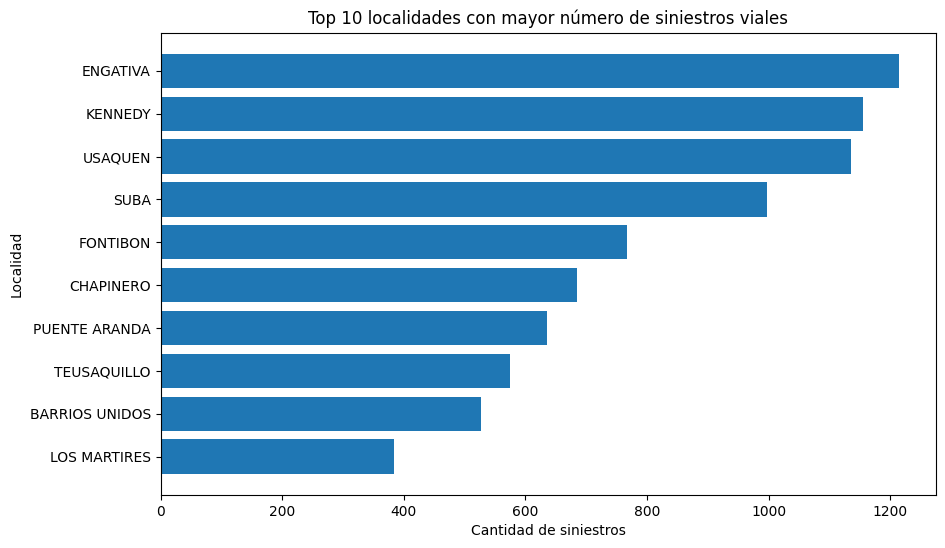

In [22]:
top10_localidades = siniestros_por_localidad.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10_localidades["LOCALIDAD"], top10_localidades["cantidad_siniestros"])
plt.gca().invert_yaxis()

plt.title("Top 10 localidades con mayor número de siniestros viales")
plt.xlabel("Cantidad de siniestros")
plt.ylabel("Localidad")

plt.show()

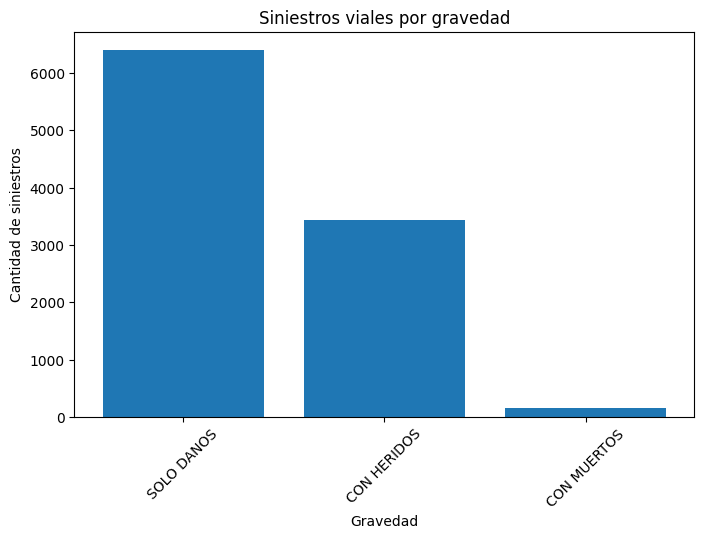

In [23]:
plt.figure(figsize=(8,5))
plt.bar(siniestros_por_gravedad["GRAVEDAD"], siniestros_por_gravedad["cantidad_siniestros"])

plt.title("Siniestros viales por gravedad")
plt.xlabel("Gravedad")
plt.ylabel("Cantidad de siniestros")

plt.xticks(rotation=45)
plt.show()

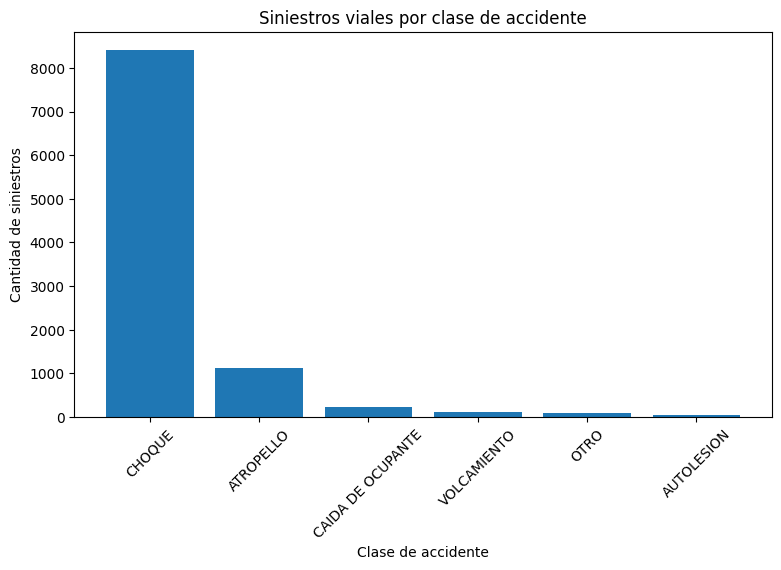

In [24]:
plt.figure(figsize=(9,5))
plt.bar(siniestros_por_clase["CLASE_ACC"], siniestros_por_clase["cantidad_siniestros"])

plt.title("Siniestros viales por clase de accidente")
plt.xlabel("Clase de accidente")
plt.ylabel("Cantidad de siniestros")

plt.xticks(rotation=45)
plt.show()

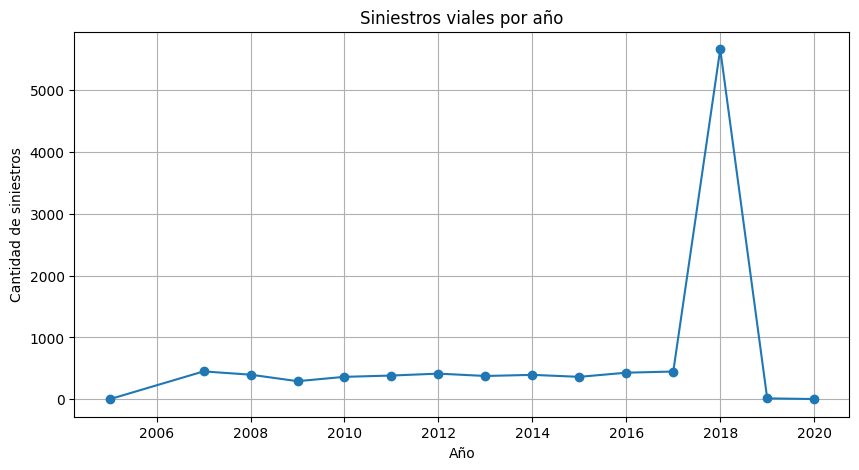

In [25]:
plt.figure(figsize=(10,5))
plt.plot(
    siniestros_por_anio["ANO_OCURRENCIA_ACC"],
    siniestros_por_anio["cantidad_siniestros"],
    marker="o"
)

plt.title("Siniestros viales por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de siniestros")

plt.grid(True)
plt.show()

In [26]:
url_accidentes = "https://sig.simur.gov.co/arcgis/rest/services/Accidentalidad/AccidentalidadAnalisis/FeatureServer/2/query"

params_count = {
    "where": "1=1",
    "returnCountOnly": "true",
    "f": "json"
}

response_count = requests.get(url_accidentes, params=params_count)
total_registros = response_count.json()["count"]

print("Total de registros en la capa ACCIDENTE:", total_registros)

Total de registros en la capa ACCIDENTE: 900302


In [27]:
anios = list(range(2007, 2027))

conteo_anios = []

for anio in anios:
    params = {
        "where": f"ANO_OCURRENCIA_ACC = {anio}",
        "returnCountOnly": "true",
        "f": "json"
    }
    
    response = requests.get(url_accidentes, params=params)
    count = response.json().get("count", 0)
    
    conteo_anios.append({
        "anio": anio,
        "cantidad_siniestros": count
    })

df_conteo_anios = pd.DataFrame(conteo_anios)

df_conteo_anios

,anio,cantidad_siniestros
0,2007,59538
1,2008,56917
2,2009,44277
3,2010,53654
4,2011,55717
5,2012,57960
6,2013,58109
7,2014,56358
8,2015,55557
9,2016,63655


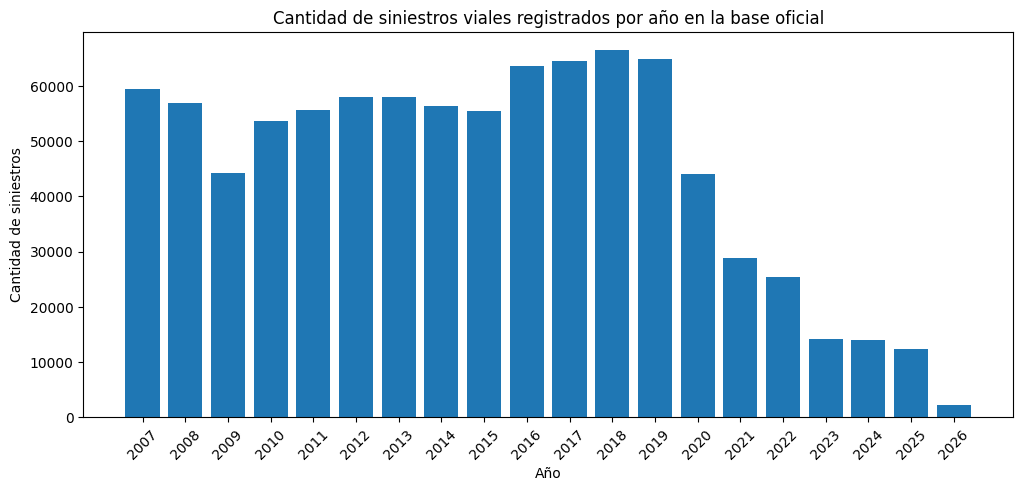

In [28]:
plt.figure(figsize=(12,5))
plt.bar(df_conteo_anios["anio"], df_conteo_anios["cantidad_siniestros"])

plt.title("Cantidad de siniestros viales registrados por año en la base oficial")
plt.xlabel("Año")
plt.ylabel("Cantidad de siniestros")
plt.xticks(df_conteo_anios["anio"], rotation=45)

plt.show()

In [29]:
df_conteo_anios.to_csv(REPORTS / "auditoria_conteo_siniestros_por_anio.csv", index=False)
print("Auditoría anual guardada correctamente en:", REPORTS)

Auditoría anual guardada correctamente en: C:\Users\jorge\Documents\viasegura_ai\outputs\reports


In [30]:
where_periodo = "ANO_OCURRENCIA_ACC >= 2016 AND ANO_OCURRENCIA_ACC <= 2019"

params_periodo = {
    "where": where_periodo,
    "returnCountOnly": "true",
    "f": "json"
}

response_periodo = requests.get(url_accidentes, params=params_periodo)
total_periodo = response_periodo.json()["count"]

print("Total de registros 2016-2019:", total_periodo)

Total de registros 2016-2019: 259829


In [31]:
def descargar_capa_arcgis_por_periodo(url_base, where, registros_por_bloque=2000):
    """
    Descarga datos de ArcGIS FeatureServer usando paginación.
    La descarga queda filtrada por una condición WHERE.
    """
    
    params_count = {
        "where": where,
        "returnCountOnly": "true",
        "f": "json"
    }
    
    total = requests.get(url_base, params=params_count, timeout=60).json()["count"]
    print("Total de registros a descargar:", total)
    
    todos_los_datos = []
    offset = 0
    
    while offset < total:
        params = {
            "where": where,
            "outFields": "*",
            "f": "geojson",
            "resultRecordCount": registros_por_bloque,
            "resultOffset": offset,
            "orderByFields": "OBJECTID ASC"
        }
        
        response = requests.get(url_base, params=params, timeout=120)
        
        if response.status_code != 200:
            print("Error en la descarga:", response.status_code)
            break
        
        data = response.json()
        
        if "features" not in data or len(data["features"]) == 0:
            print("No llegaron más registros.")
            break
        
        gdf_temp = gpd.GeoDataFrame.from_features(data["features"], crs="EPSG:4686")
        todos_los_datos.append(gdf_temp)
        
        offset += registros_por_bloque
        print(f"Descargados {min(offset, total)} de {total}")
    
    gdf_final = pd.concat(todos_los_datos, ignore_index=True)
    
    return gdf_final

In [32]:
# Descarga exploratoria — se salta si el CSV final ya existe
_p_raw = DATA_RAW / 'accidentes_bogota_2016_2019_raw.csv'
if _p_raw.exists() and _p_raw.stat().st_size > 10_000_000:
    print(f'CSV final ya existe ({_p_raw.stat().st_size/1e6:.1f} MB) — descarga exploratoria omitida.')
    accidentes_2016_2019 = None  # no se usa en el pipeline final
else:
    accidentes_2016_2019 = descargar_capa_arcgis_por_periodo(
        url_base=url_accidentes,
        where=where_periodo,
        registros_por_bloque=2000
    )
    print('Registros descargados:', len(accidentes_2016_2019))


CSV final ya existe (69.0 MB) — descarga exploratoria omitida.


In [33]:
import time

In [34]:
ruta_chunks = DATA_RAW / "chunks_accidentes_2016_2019"
ruta_chunks.mkdir(parents=True, exist_ok=True)
print("Carpeta de chunks lista:", ruta_chunks)

Carpeta de chunks lista: C:\Users\jorge\Documents\viasegura_ai\data\raw\chunks_accidentes_2016_2019


In [35]:
def descargar_accidentes_por_anio_seguro(url_base, anio, registros_por_bloque=1000, max_reintentos=5):
    """
    Descarga accidentes de un año específico desde ArcGIS.
    Guarda cada bloque como CSV para no perder avances si falla la conexión.
    """
    
    where = f"ANO_OCURRENCIA_ACC = {anio}"
    
    params_count = {
        "where": where,
        "returnCountOnly": "true",
        "f": "json"
    }
    
    total = requests.get(url_base, params=params_count, timeout=60).json()["count"]
    print(f"\nAño {anio} - Total de registros:", total)
    
    offset = 0
    
    while offset < total:
        archivo_chunk = ruta_chunks / f"accidentes_{anio}_offset_{offset}.csv"
        
        # Si el bloque ya existe, no lo vuelve a descargar
        if archivo_chunk.exists():
            print(f"Año {anio} - Offset {offset} ya existe. Se omite.")
            offset += registros_por_bloque
            continue
        
        params = {
            "where": where,
            "outFields": "*",
            "f": "geojson",
            "resultRecordCount": registros_por_bloque,
            "resultOffset": offset,
            "orderByFields": "OBJECTID ASC"
        }
        
        exito = False
        
        for intento in range(1, max_reintentos + 1):
            try:
                response = requests.get(url_base, params=params, timeout=120)
                
                if response.status_code != 200:
                    print(f"Error HTTP {response.status_code}. Intento {intento}/{max_reintentos}")
                    time.sleep(5)
                    continue
                
                data = response.json()
                
                if "features" not in data or len(data["features"]) == 0:
                    print("No llegaron más registros.")
                    return
                
                gdf_temp = gpd.GeoDataFrame.from_features(data["features"], crs="EPSG:4686")
                gdf_temp.to_csv(archivo_chunk, index=False)
                
                print(f"Año {anio} - Descargados {min(offset + registros_por_bloque, total)} de {total}")
                
                exito = True
                break
            
            except Exception as e:
                print(f"Fallo en año {anio}, offset {offset}. Intento {intento}/{max_reintentos}")
                print("Error:", e)
                time.sleep(10)
        
        if not exito:
            print(f"No se pudo descargar año {anio}, offset {offset}. Deteniendo para revisar.")
            break
        
        offset += registros_por_bloque
        time.sleep(0.5)

In [36]:
# Descarga por año — se salta si los chunks ya están en disco
_ruta_chunks_check = DATA_RAW / 'chunks_accidentes_2016_2019'
_chunks_ok = (
    _ruta_chunks_check.exists()
    and len(list(_ruta_chunks_check.glob('accidentes_201*.csv'))) >= 4
)
if _chunks_ok:
    _n_chunks = len(list(_ruta_chunks_check.glob('accidentes_201*.csv')))
    print(f'Chunks ya presentes ({_n_chunks} archivos) — descarga omitida.')
else:
    for anio in [2016, 2017, 2018, 2019]:
        descargar_accidentes_por_anio_seguro(
            url_base=url_accidentes,
            anio=anio,
            registros_por_bloque=1000
        )



Año 2016 - Total de registros: 63655
Año 2016 - Offset 0 ya existe. Se omite.
Año 2016 - Offset 1000 ya existe. Se omite.
Año 2016 - Offset 2000 ya existe. Se omite.
Año 2016 - Offset 3000 ya existe. Se omite.
Año 2016 - Offset 4000 ya existe. Se omite.
Año 2016 - Offset 5000 ya existe. Se omite.
Año 2016 - Offset 6000 ya existe. Se omite.
Año 2016 - Offset 7000 ya existe. Se omite.
Año 2016 - Offset 8000 ya existe. Se omite.
Año 2016 - Offset 9000 ya existe. Se omite.
Año 2016 - Offset 10000 ya existe. Se omite.
Año 2016 - Offset 11000 ya existe. Se omite.
Año 2016 - Offset 12000 ya existe. Se omite.
Año 2016 - Offset 13000 ya existe. Se omite.
Año 2016 - Offset 14000 ya existe. Se omite.
Año 2016 - Offset 15000 ya existe. Se omite.
Año 2016 - Offset 16000 ya existe. Se omite.
Año 2016 - Offset 17000 ya existe. Se omite.
Año 2016 - Offset 18000 ya existe. Se omite.
Año 2016 - Offset 19000 ya existe. Se omite.
Año 2016 - Offset 20000 ya existe. Se omite.
Año 2016 - Offset 21000 ya exi


Año 2017 - Total de registros: 64617
Año 2017 - Offset 0 ya existe. Se omite.
Año 2017 - Offset 1000 ya existe. Se omite.
Año 2017 - Offset 2000 ya existe. Se omite.
Año 2017 - Offset 3000 ya existe. Se omite.
Año 2017 - Offset 4000 ya existe. Se omite.
Año 2017 - Offset 5000 ya existe. Se omite.
Año 2017 - Offset 6000 ya existe. Se omite.
Año 2017 - Offset 7000 ya existe. Se omite.
Año 2017 - Offset 8000 ya existe. Se omite.
Año 2017 - Offset 9000 ya existe. Se omite.
Año 2017 - Offset 10000 ya existe. Se omite.
Año 2017 - Offset 11000 ya existe. Se omite.
Año 2017 - Offset 12000 ya existe. Se omite.
Año 2017 - Offset 13000 ya existe. Se omite.
Año 2017 - Offset 14000 ya existe. Se omite.
Año 2017 - Offset 15000 ya existe. Se omite.
Año 2017 - Offset 16000 ya existe. Se omite.
Año 2017 - Offset 17000 ya existe. Se omite.
Año 2017 - Offset 18000 ya existe. Se omite.
Año 2017 - Offset 19000 ya existe. Se omite.
Año 2017 - Offset 20000 ya existe. Se omite.
Año 2017 - Offset 21000 ya exi


Año 2018 - Total de registros: 66531
Año 2018 - Offset 0 ya existe. Se omite.
Año 2018 - Offset 1000 ya existe. Se omite.
Año 2018 - Offset 2000 ya existe. Se omite.
Año 2018 - Offset 3000 ya existe. Se omite.
Año 2018 - Offset 4000 ya existe. Se omite.
Año 2018 - Offset 5000 ya existe. Se omite.
Año 2018 - Offset 6000 ya existe. Se omite.
Año 2018 - Offset 7000 ya existe. Se omite.
Año 2018 - Offset 8000 ya existe. Se omite.
Año 2018 - Offset 9000 ya existe. Se omite.
Año 2018 - Offset 10000 ya existe. Se omite.
Año 2018 - Offset 11000 ya existe. Se omite.
Año 2018 - Offset 12000 ya existe. Se omite.
Año 2018 - Offset 13000 ya existe. Se omite.
Año 2018 - Offset 14000 ya existe. Se omite.
Año 2018 - Offset 15000 ya existe. Se omite.
Año 2018 - Offset 16000 ya existe. Se omite.
Año 2018 - Offset 17000 ya existe. Se omite.
Año 2018 - Offset 18000 ya existe. Se omite.
Año 2018 - Offset 19000 ya existe. Se omite.
Año 2018 - Offset 20000 ya existe. Se omite.
Año 2018 - Offset 21000 ya exi


Año 2019 - Total de registros: 65026
Año 2019 - Offset 0 ya existe. Se omite.
Año 2019 - Offset 1000 ya existe. Se omite.
Año 2019 - Offset 2000 ya existe. Se omite.
Año 2019 - Offset 3000 ya existe. Se omite.
Año 2019 - Offset 4000 ya existe. Se omite.
Año 2019 - Offset 5000 ya existe. Se omite.
Año 2019 - Offset 6000 ya existe. Se omite.
Año 2019 - Offset 7000 ya existe. Se omite.
Año 2019 - Offset 8000 ya existe. Se omite.
Año 2019 - Offset 9000 ya existe. Se omite.
Año 2019 - Offset 10000 ya existe. Se omite.
Año 2019 - Offset 11000 ya existe. Se omite.
Año 2019 - Offset 12000 ya existe. Se omite.
Año 2019 - Offset 13000 ya existe. Se omite.
Año 2019 - Offset 14000 ya existe. Se omite.
Año 2019 - Offset 15000 ya existe. Se omite.
Año 2019 - Offset 16000 ya existe. Se omite.
Año 2019 - Offset 17000 ya existe. Se omite.
Año 2019 - Offset 18000 ya existe. Se omite.
Año 2019 - Offset 19000 ya existe. Se omite.
Año 2019 - Offset 20000 ya existe. Se omite.
Año 2019 - Offset 21000 ya exi

In [37]:
import pandas as pd

_p_raw_csv = DATA_RAW / 'accidentes_bogota_2016_2019_raw.csv'
ruta_chunks = DATA_RAW / 'chunks_accidentes_2016_2019'
archivos_chunks = sorted(ruta_chunks.glob('accidentes_201*.csv')) if ruta_chunks.exists() else []
print(f'Chunks encontrados: {len(archivos_chunks)}')


Chunks encontrados: 0


In [38]:
if archivos_chunks:
    lista_df = [pd.read_csv(a) for a in archivos_chunks]
    accidentes_2016_2019_raw = pd.concat(lista_df, ignore_index=True)
    print(f'Cargado desde chunks: {len(accidentes_2016_2019_raw):,} filas')
elif _p_raw_csv.exists():
    accidentes_2016_2019_raw = pd.read_csv(_p_raw_csv)
    print(f'Cargado desde CSV existente: {len(accidentes_2016_2019_raw):,} filas')
else:
    raise FileNotFoundError('No se encontraron chunks ni CSV base. Ejecuta la descarga primero.')


Cargado desde CSV existente: 260,831 filas


In [39]:
print("Filas descargadas y unidas:", len(accidentes_2016_2019_raw))
print("Filas esperadas 2016-2019:", total_periodo)
print("Diferencia:", total_periodo - len(accidentes_2016_2019_raw))

Filas descargadas y unidas: 260831
Filas esperadas 2016-2019: 259829
Diferencia: -1002


In [40]:
accidentes_2016_2019_raw["ANO_OCURRENCIA_ACC"].value_counts().sort_index()

ANO_OCURRENCIA_ACC
2016    63932
2017    64828
2018    66816
2019    65255
Name: count, dtype: int64

In [41]:
print("Duplicados por OBJECTID:", accidentes_2016_2019_raw["OBJECTID"].duplicated().sum())
print("Duplicados por CODIGO_ACCIDENTE:", accidentes_2016_2019_raw["CODIGO_ACCIDENTE"].duplicated().sum())
print("Duplicados por FORMULARIO:", accidentes_2016_2019_raw["FORMULARIO"].duplicated().sum())

Duplicados por OBJECTID: 0
Duplicados por CODIGO_ACCIDENTE: 0
Duplicados por FORMULARIO: 0


In [42]:
accidentes_2016_2019_raw.to_csv(DATA_RAW / "accidentes_bogota_2016_2019_raw.csv", index=False)
print("Base oficial 2016-2019 guardada correctamente en:", DATA_RAW)

Base oficial 2016-2019 guardada correctamente en: C:\Users\jorge\Documents\viasegura_ai\data\raw


In [43]:
df_limpia = accidentes_2016_2019_raw.copy()

print("Filas iniciales:", len(df_limpia))
print("Columnas iniciales:", df_limpia.shape[1])

Filas iniciales: 260831
Columnas iniciales: 22


In [44]:
columnas_utiles = [
    "OBJECTID",
    "FORMULARIO",
    "CODIGO_ACCIDENTE",
    "FECHA_OCURRENCIA_ACC",
    "HORA_OCURRENCIA_ACC",
    "ANO_OCURRENCIA_ACC",
    "MES_OCURRENCIA_ACC",
    "DIA_OCURRENCIA_ACC",
    "DIRECCION",
    "GRAVEDAD",
    "CLASE_ACC",
    "LOCALIDAD",
    "MUNICIPIO",
    "LATITUD",
    "LONGITUD",
    "BARRIO",
    "MVINOMBRE",
    "DISTANCIA_VIA"
]

df_limpia = df_limpia[columnas_utiles].copy()

df_limpia.head()

,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA_ACC,HORA_OCURRENCIA_ACC,ANO_OCURRENCIA_ACC,MES_OCURRENCIA_ACC,DIA_OCURRENCIA_ACC,DIRECCION,GRAVEDAD,CLASE_ACC,LOCALIDAD,MUNICIPIO,LATITUD,LONGITUD,BARRIO,MVINOMBRE,DISTANCIA_VIA
0,8,A000402862,4447845,1465344000000,21:30:00,2016,JUNIO,MIERCOLES,KR 27-CL 9 14,SOLO DANOS,CHOQUE,LOS MARTIRES,BOGOTA DC,4.607648,-74.092901,RICAURTE,AVENIDA GENERAL SANTANDER,0.0
1,13,A000551010,4468708,1482796800000,19:00:00,2016,DICIEMBRE,MARTES,CL 69A-KR 89A 02,CON HERIDOS,CHOQUE,ENGATIVA,BOGOTA DC,4.693578,-74.110585,FLORIDA BLANCA,SIN_NMG,0.2
2,17,A22245,4467629,1481846400000,15:00:00,2016,DICIEMBRE,VIERNES,KR 21-CL 127 03,SOLO DANOS,CHOQUE,USAQUEN,BOGOTA DC,4.706539,-74.051613,LA CALLEJA,SIN_NMG,0.0
3,28,A000473024,4459693,1475539200000,12:15:00,2016,OCTUBRE,MARTES,KR 77-CL 19 02,SOLO DANOS,CHOQUE,FONTIBON,BOGOTA DC,4.654839,-74.128700,CIUDAD HAYUELOS,SIN_NMG,6.7
4,32,A000403683,4448989,1466380800000,11:50:00,2016,JUNIO,LUNES,KR 11-CL 72 02,SOLO DANOS,CHOQUE,CHAPINERO,BOGOTA DC,4.657149,-74.058813,PORCIUNCULA,AVENIDA GERMAN ARCINIEGAS,0.0


In [45]:
df_limpia["FECHA_OCURRENCIA_ACC"] = pd.to_datetime(
    df_limpia["FECHA_OCURRENCIA_ACC"],
    unit="ms",
    errors="coerce"
)

df_limpia["LATITUD"] = pd.to_numeric(df_limpia["LATITUD"], errors="coerce")
df_limpia["LONGITUD"] = pd.to_numeric(df_limpia["LONGITUD"], errors="coerce")

df_limpia[["FECHA_OCURRENCIA_ACC", "LATITUD", "LONGITUD"]].head()

,FECHA_OCURRENCIA_ACC,LATITUD,LONGITUD
0,2016-06-08,4.607648,-74.092901
1,2016-12-27,4.693578,-74.110585
2,2016-12-16,4.706539,-74.051613
3,2016-10-04,4.654839,-74.128700
4,2016-06-20,4.657149,-74.058813


In [46]:
columnas_texto = [
    "MES_OCURRENCIA_ACC",
    "DIA_OCURRENCIA_ACC",
    "DIRECCION",
    "GRAVEDAD",
    "CLASE_ACC",
    "LOCALIDAD",
    "MUNICIPIO",
    "BARRIO",
    "MVINOMBRE"
]

for col in columnas_texto:
    df_limpia[col] = df_limpia[col].astype("string").str.strip().str.upper()

In [47]:
filas_antes = len(df_limpia)

df_limpia = df_limpia.dropna(subset=["LATITUD", "LONGITUD"])

df_limpia = df_limpia[
    (df_limpia["LATITUD"] > 4.0) &
    (df_limpia["LATITUD"] < 5.0) &
    (df_limpia["LONGITUD"] > -75.0) &
    (df_limpia["LONGITUD"] < -73.0)
]

filas_despues = len(df_limpia)

print("Filas antes:", filas_antes)
print("Filas después de limpiar coordenadas:", filas_despues)
print("Filas eliminadas:", filas_antes - filas_despues)

Filas antes: 260831
Filas después de limpiar coordenadas: 260831
Filas eliminadas: 0


In [48]:
puntaje_gravedad = {
    "SOLO DANOS": 1,
    "SOLO DAÑOS": 1,
    "CON HERIDOS": 3,
    "CON MUERTOS": 5
}

df_limpia["puntaje_gravedad"] = df_limpia["GRAVEDAD"].map(puntaje_gravedad)

df_limpia[["GRAVEDAD", "puntaje_gravedad"]].drop_duplicates()

,GRAVEDAD,puntaje_gravedad
0,SOLO DANOS,1
1,CON HERIDOS,3
153,CON MUERTOS,5


In [49]:
df_limpia["puntaje_gravedad"].isnull().sum()

np.int64(0)

In [50]:
df_limpia.to_csv(DATA_PROCESSED / "accidentes_bogota_2016_2019_limpio.csv", index=False)
print("Base limpia guardada correctamente en:", DATA_PROCESSED)

Base limpia guardada correctamente en: C:\Users\jorge\Documents\viasegura_ai\data\processed


In [51]:
resumen_calidad = pd.DataFrame([
    {
        "base": "accidentes_bogota_2016_2019_limpio",
        "periodo": "2016-2019",
        "filas_raw": len(accidentes_2016_2019_raw),
        "filas_limpias": len(df_limpia),
        "filas_eliminadas_limpieza": len(accidentes_2016_2019_raw) - len(df_limpia),
        "duplicados_objectid_raw": accidentes_2016_2019_raw["OBJECTID"].duplicated().sum(),
        "duplicados_objectid_limpia": df_limpia["OBJECTID"].duplicated().sum(),
        "nulos_latitud": df_limpia["LATITUD"].isnull().sum(),
        "nulos_longitud": df_limpia["LONGITUD"].isnull().sum(),
        "nulos_puntaje_gravedad": df_limpia["puntaje_gravedad"].isnull().sum()
    }
])

resumen_calidad

,base,periodo,filas_raw,filas_limpias,filas_eliminadas_limpieza,duplicados_objectid_raw,duplicados_objectid_limpia,nulos_latitud,nulos_longitud,nulos_puntaje_gravedad
0,accidentes_bogota_2016_2019_limpio,2016-2019,260831,260831,0,0,0,0,0,0


In [52]:
resumen_calidad.to_csv(REPORTS / "resumen_calidad_datos_2016_2019.csv", index=False)
print("Resumen de calidad guardado correctamente en:", REPORTS)

Resumen de calidad guardado correctamente en: C:\Users\jorge\Documents\viasegura_ai\outputs\reports


In [53]:
tabla_localidad = (
    df_limpia
    .groupby("LOCALIDAD")
    .agg(
        cantidad_siniestros=("OBJECTID", "count"),
        criticidad_total=("puntaje_gravedad", "sum"),
        criticidad_promedio=("puntaje_gravedad", "mean")
    )
    .reset_index()
    .sort_values("criticidad_total", ascending=False)
)

tabla_localidad.head(10)

,LOCALIDAD,cantidad_siniestros,criticidad_total,criticidad_promedio
8,KENNEDY,30716,57196,1.862091
6,ENGATIVA,27782,45642,1.642862
14,SUBA,24672,41484,1.681420
17,USAQUEN,25806,37054,1.435868
7,FONTIBON,22135,33835,1.528575
10,PUENTE ARANDA,17872,31052,1.737466
4,CHAPINERO,16834,24594,1.460972
2,BOSA,11654,23442,2.011498
15,TEUSAQUILLO,13694,21562,1.574558
1,BARRIOS UNIDOS,13681,21385,1.563117


In [54]:
tabla_gravedad = (
    df_limpia
    .groupby("GRAVEDAD")
    .agg(
        cantidad_siniestros=("OBJECTID", "count"),
        criticidad_total=("puntaje_gravedad", "sum")
    )
    .reset_index()
    .sort_values("criticidad_total", ascending=False)
)

tabla_gravedad

,GRAVEDAD,cantidad_siniestros,criticidad_total
0,CON HERIDOS,84730,254190
2,SOLO DANOS,171904,171904
1,CON MUERTOS,4197,20985


In [55]:
tabla_clase = (
    df_limpia
    .groupby("CLASE_ACC")
    .agg(
        cantidad_siniestros=("OBJECTID", "count"),
        criticidad_total=("puntaje_gravedad", "sum"),
        criticidad_promedio=("puntaje_gravedad", "mean")
    )
    .reset_index()
    .sort_values("criticidad_total", ascending=False)
)

tabla_clase

,CLASE_ACC,cantidad_siniestros,criticidad_total,criticidad_promedio
3,CHOQUE,223140,330734,1.482182
0,ATROPELLO,26811,84335,3.145537
2,CAIDA DE OCUPANTE,6318,18982,3.004432
6,VOLCAMIENTO,3473,10053,2.894616
5,OTRO,1041,2895,2.780980
4,INCENDIO,36,44,1.222222
1,AUTOLESION,12,36,3.000000


In [56]:
tabla_anio = (
    df_limpia
    .groupby("ANO_OCURRENCIA_ACC")
    .agg(
        cantidad_siniestros=("OBJECTID", "count"),
        criticidad_total=("puntaje_gravedad", "sum"),
        criticidad_promedio=("puntaje_gravedad", "mean")
    )
    .reset_index()
    .sort_values("ANO_OCURRENCIA_ACC")
)

tabla_anio

,ANO_OCURRENCIA_ACC,cantidad_siniestros,criticidad_total,criticidad_promedio
0,2016,63932,107600,1.683038
1,2017,64828,107708,1.661443
2,2018,66816,116516,1.743834
3,2019,65255,115255,1.766225


In [57]:
tabla_localidad.to_csv(REPORTS / "tabla_localidad_2016_2019.csv", index=False)
tabla_gravedad.to_csv(REPORTS / "tabla_gravedad_2016_2019.csv", index=False)
tabla_clase.to_csv(REPORTS / "tabla_clase_accidente_2016_2019.csv", index=False)
tabla_anio.to_csv(REPORTS / "tabla_anio_2016_2019.csv", index=False)
print("Tablas de análisis guardadas correctamente en:", REPORTS)

Tablas de análisis guardadas correctamente en: C:\Users\jorge\Documents\viasegura_ai\outputs\reports


In [58]:
import pandas as pd
import geopandas as gpd
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
from pathlib import Path

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [59]:
df_limpia = pd.read_csv(DATA_PROCESSED / "accidentes_bogota_2016_2019_limpio.csv")
print("Base limpia cargada correctamente.")
print("Filas y columnas:", df_limpia.shape)
df_limpia.head()

Base limpia cargada correctamente.
Filas y columnas: (260831, 19)


,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA_ACC,HORA_OCURRENCIA_ACC,ANO_OCURRENCIA_ACC,MES_OCURRENCIA_ACC,DIA_OCURRENCIA_ACC,DIRECCION,GRAVEDAD,CLASE_ACC,LOCALIDAD,MUNICIPIO,LATITUD,LONGITUD,BARRIO,MVINOMBRE,DISTANCIA_VIA,puntaje_gravedad
0,8,A000402862,4447845,2016-06-08,21:30:00,2016,JUNIO,MIERCOLES,KR 27-CL 9 14,SOLO DANOS,CHOQUE,LOS MARTIRES,BOGOTA DC,4.607648,-74.092901,RICAURTE,AVENIDA GENERAL SANTANDER,0.0,1
1,13,A000551010,4468708,2016-12-27,19:00:00,2016,DICIEMBRE,MARTES,CL 69A-KR 89A 02,CON HERIDOS,CHOQUE,ENGATIVA,BOGOTA DC,4.693578,-74.110585,FLORIDA BLANCA,SIN_NMG,0.2,3
2,17,A22245,4467629,2016-12-16,15:00:00,2016,DICIEMBRE,VIERNES,KR 21-CL 127 03,SOLO DANOS,CHOQUE,USAQUEN,BOGOTA DC,4.706539,-74.051613,LA CALLEJA,SIN_NMG,0.0,1
3,28,A000473024,4459693,2016-10-04,12:15:00,2016,OCTUBRE,MARTES,KR 77-CL 19 02,SOLO DANOS,CHOQUE,FONTIBON,BOGOTA DC,4.654839,-74.128700,CIUDAD HAYUELOS,SIN_NMG,6.7,1
4,32,A000403683,4448989,2016-06-20,11:50:00,2016,JUNIO,LUNES,KR 11-CL 72 02,SOLO DANOS,CHOQUE,CHAPINERO,BOGOTA DC,4.657149,-74.058813,PORCIUNCULA,AVENIDA GERMAN ARCINIEGAS,0.0,1


In [60]:
tabla_localidad = (
    df_limpia
    .groupby("LOCALIDAD")
    .agg(
        cantidad_siniestros=("OBJECTID", "count"),
        criticidad_total=("puntaje_gravedad", "sum"),
        criticidad_promedio=("puntaje_gravedad", "mean")
    )
    .reset_index()
    .sort_values("criticidad_total", ascending=False)
)

tabla_gravedad = (
    df_limpia
    .groupby("GRAVEDAD")
    .agg(
        cantidad_siniestros=("OBJECTID", "count"),
        criticidad_total=("puntaje_gravedad", "sum")
    )
    .reset_index()
    .sort_values("criticidad_total", ascending=False)
)

tabla_clase = (
    df_limpia
    .groupby("CLASE_ACC")
    .agg(
        cantidad_siniestros=("OBJECTID", "count"),
        criticidad_total=("puntaje_gravedad", "sum"),
        criticidad_promedio=("puntaje_gravedad", "mean")
    )
    .reset_index()
    .sort_values("criticidad_total", ascending=False)
)

tabla_anio = (
    df_limpia
    .groupby("ANO_OCURRENCIA_ACC")
    .agg(
        cantidad_siniestros=("OBJECTID", "count"),
        criticidad_total=("puntaje_gravedad", "sum"),
        criticidad_promedio=("puntaje_gravedad", "mean")
    )
    .reset_index()
    .sort_values("ANO_OCURRENCIA_ACC")
)

print("Tablas recreadas correctamente.")

Tablas recreadas correctamente.


In [61]:
tabla_localidad.head(10)

,LOCALIDAD,cantidad_siniestros,criticidad_total,criticidad_promedio
8,KENNEDY,30716,57196,1.862091
6,ENGATIVA,27782,45642,1.642862
14,SUBA,24672,41484,1.681420
17,USAQUEN,25806,37054,1.435868
7,FONTIBON,22135,33835,1.528575
10,PUENTE ARANDA,17872,31052,1.737466
4,CHAPINERO,16834,24594,1.460972
2,BOSA,11654,23442,2.011498
15,TEUSAQUILLO,13694,21562,1.574558
1,BARRIOS UNIDOS,13681,21385,1.563117


In [62]:
df_mapa = df_limpia.copy()

df_mapa["LAT_REDONDEADA"] = df_mapa["LATITUD"].round(3)
df_mapa["LON_REDONDEADA"] = df_mapa["LONGITUD"].round(3)

puntos_calor = (
    df_mapa
    .groupby(["LAT_REDONDEADA", "LON_REDONDEADA"])
    .agg(
        cantidad_siniestros=("OBJECTID", "count"),
        criticidad_total=("puntaje_gravedad", "sum")
    )
    .reset_index()
)

print("Puntos agrupados para el mapa:", len(puntos_calor))
puntos_calor.head()

Puntos agrupados para el mapa: 17130


,LAT_REDONDEADA,LON_REDONDEADA,cantidad_siniestros,criticidad_total
0,4.303,-74.034,2,10
1,4.460,-74.118,2,6
2,4.464,-74.123,2,2
3,4.465,-74.129,16,32
4,4.465,-74.123,4,8


In [63]:
mapa_calor = folium.Map(
    location=[4.65, -74.08],
    zoom_start=11,
    tiles="CartoDB positron"
)

datos_heatmap = puntos_calor[
    ["LAT_REDONDEADA", "LON_REDONDEADA", "criticidad_total"]
].values.tolist()

HeatMap(
    datos_heatmap,
    radius=12,
    blur=15,
    max_zoom=13
).add_to(mapa_calor)

mapa_calor

In [64]:
mapa_calor.save(MAPS / "mapa_calor_criticidad_siniestros_2016_2019.html")
print("Mapa de calor guardado correctamente en:", MAPS)

Mapa de calor guardado correctamente en: C:\Users\jorge\Documents\viasegura_ai\outputs\maps


In [65]:
print("Carpeta del notebook:", Path(__file__).parent if '__file__' in dir() else Path.cwd())
print("Raíz del proyecto:", PROJECT_ROOT)
print("Archivos en la raíz:")
for item in PROJECT_ROOT.iterdir():
    print(" ", item.name)

Carpeta del notebook: C:\Users\jorge\Documents\viasegura_ai\notebooks
Raíz del proyecto: C:\Users\jorge\Documents\viasegura_ai
Archivos en la raíz:
  .claude
  .env
  .gitignore
  .ipynb_checkpoints
  .venv
  .vscode
  add_sec12_13_result.txt
  add_sec12_13_stdout.txt
  add_sections12_13.py
  app
  CHANGELOG.md
  config.py
  data
  DATA_SOURCES.md
  DECISIONS.md
  fix_ipi_nb02.py
  fix_ipi_nb02_output.txt
  fix_out.txt
  fix_sec9_cells.py
  inspect_out.txt
  inspect_sec9_10.py
  leer_resultados.py
  memory
  notebooks
  outputs
  PLAN.md
  pyproject.toml
  README.md
  resultados_sec9_10.txt
  run_sec12_13.py
  run_sec12_13_out.txt
  run_sec9_10.py
  scripts
  sql
  update_nb03_31.py
  uv.lock
  __pycache__


In [66]:
rutas_clave = [
    PROJECT_ROOT / "notebooks" / "01_exploracion_datos_siniestralidad.ipynb",
    DATA_RAW / "accidentes_bogota_2016_2019_raw.csv",
    DATA_PROCESSED / "accidentes_bogota_2016_2019_limpio.csv",
    MAPS / "mapa_calor_criticidad_siniestros_2016_2019.html",
    REPORTS / "tabla_localidad_2016_2019.csv"
]
for ruta in rutas_clave:
    estado = "✓" if ruta.exists() else "✗"
    print(f"{estado} {ruta}")

✓ C:\Users\jorge\Documents\viasegura_ai\notebooks\01_exploracion_datos_siniestralidad.ipynb
✓ C:\Users\jorge\Documents\viasegura_ai\data\raw\accidentes_bogota_2016_2019_raw.csv
✓ C:\Users\jorge\Documents\viasegura_ai\data\processed\accidentes_bogota_2016_2019_limpio.csv
✓ C:\Users\jorge\Documents\viasegura_ai\outputs\maps\mapa_calor_criticidad_siniestros_2016_2019.html
✓ C:\Users\jorge\Documents\viasegura_ai\outputs\reports\tabla_localidad_2016_2019.csv
